# 🔬 Robust Hybrid Delayed Analyzer
This notebook combines our high-resolution `numpy` FFT Transient Extractor with the powerful `Listener.py` Phase-Locked Loop (Flywheel).

Here, `Listener` only acts to **guide** our expectations. Once `Listener` expects a beat, we scan the 5-second Lookahead Buffer exclusively analyzing our isolated high-resolution Spectral Flux to perfectly snap the event onto the exact physical acoustic transient!


In [1]:
import librosa
import numpy as np
import torchaudio
import torch
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Import core infrastructure
import core.Listener as ListenerModule
from IPython.display import display, clear_output

def default_infos():
    return {
        "startServer"     : False ,
        "useGlobalMatrix" : False ,
        "useMicrophone"   : True  ,
        "HARDWARE_MODE"   : "simulation",
        "onRaspberry"     : False  ,

        "printTimeOfCalculation" : False ,
        "printModesDetails"      : True ,
        "printMicrophoneDetails" : False ,
        "printAppDetails"        : False ,
        "printAsservmentDetails" : False ,
        "printConfigurationLoads": False ,
        "printConfigChanges"     : False ,

        "modesToPrintDetails"    : ["PSG"]
    }

AUDIO_FILE = 'mp3_files/Nightcall.mp3'



### 1. The Ground Truth Evaluation Benchmark
Generating base metrics leveraging librosa.


In [2]:
print(f"Loading {AUDIO_FILE} full audio for Ground Truth Benchmarks...")
y_full, sr = librosa.load(AUDIO_FILE)

print("Running non-causal Librosa Beat Track...")
onset_env_full = librosa.onset.onset_strength(y=y_full, sr=sr)
tempo_librosa, beat_frames_true = librosa.beat.beat_track(onset_envelope=onset_env_full, sr=sr)
true_beat_times = librosa.frames_to_time(beat_frames_true, sr=sr)

# Basic Librosa sub-beats estimation (tempo / 2 shift)
true_subbeat_times = []
for i in range(len(true_beat_times) - 1):
    midpoint = (true_beat_times[i] + true_beat_times[i+1]) / 2.0
    true_subbeat_times.append(midpoint)
true_subbeat_times = np.array(true_subbeat_times)

print(f"✅ Ground Truth Extraction Complete! Main Beats: {len(true_beat_times)}, Sub Beats: {len(true_subbeat_times)}")



Loading mp3_files/Nightcall.mp3 full audio for Ground Truth Benchmarks...
Running non-causal Librosa Beat Track...
✅ Ground Truth Extraction Complete! Main Beats: 386, Sub Beats: 385


### 2. High Resolution FFT Microphones & Listener Flywheel


In [3]:
class Simulated_Microphone:
    def __init__(self, audio_file_path, bandValues, infos):
        self.bandValues = bandValues
        self.nb_of_fft_band = len(self.bandValues)
        
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        
        print(f"Loading {audio_file_path} into Simulation Buffer...")
        waveform, sr = torchaudio.load(audio_file_path)
        
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        if sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.sample_rate)
            waveform = resampler(waveform)
            
        self.full_audio = waveform.numpy().flatten()
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum
                
        # We also store an explicitly purely raw FFT tracking variable for Spectral Flux (not smoothed by the LED bins)
        self.raw_fft_history = None
        self.high_res_flux = 0.0

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        
        # 1. Update the Flywheel guide variables
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])

        # 2. Extract the high-resolution Spectral Flux for our 5-second Lookahead Snapping
        if self.raw_fft_history is not None:
            # We specifically look at mid-high frequencies for ultra-sharp transients
            # Bins 5 to 300 equate to roughly 100Hz to 6.5kHz
            freq_diff = np.maximum(0, fft_result[5:300] - self.raw_fft_history[5:300])
            self.high_res_flux = np.sum(freq_diff)
        self.raw_fft_history = fft_result



def targeted_sub_resolution_sweep(odf_buffer, base_bpm):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    best_overall_score = -float('inf')
    best_overall_bpm = base_bpm
    
    buffer_indices = np.arange(odf_size)
    bpm_evals = np.arange(max(60.0, base_bpm - 5.0), min(200.0, base_bpm + 5.0) + 0.5, 0.5)
    btrack_fps = 60.0
    
    for bpm_val in bpm_evals:
        tau_val = 60.0 * btrack_fps / bpm_val
        p_max = int(np.ceil(tau_val))
        p_scores = np.zeros(p_max)
        
        for p in range(p_max):
            phase_float = (buffer_indices - (odf_size - 1 - p)) % tau_val
            norm_phi = phase_float / tau_val
            template_vals = np.full(odf_size, -0.2)
            template_vals[(norm_phi <= 0.05) | (norm_phi >= 0.95)] = 1.0
            template_vals[(norm_phi >= 0.45) & (norm_phi <= 0.55)] = 0.6
            template_vals[(norm_phi >= 0.22) & (norm_phi <= 0.28)] = 0.3
            template_vals[(norm_phi >= 0.72) & (norm_phi <= 0.78)] = 0.3
            p_scores[p] = np.sum(weighted_buffer * template_vals)
            
        tau_max_score = np.max(p_scores)
        if tau_max_score > best_overall_score:
            best_overall_score = tau_max_score
            best_overall_bpm = bpm_val
            
    return best_overall_bpm


### 3. The Guided 5-Second Magnetic Buffer Simulator


In [4]:
infos = default_infos()
infos["printAsservmentDetails"] = False 
infos["useMicrophone"] = True

SIMULATED_FPS = 60.0
TIME_PER_FRAME = 1.0 / SIMULATED_FPS
CHUNK_SIZE_FOR_60FPS = int(44100 / SIMULATED_FPS)

class MockTime:
    def __init__(self):
        self.current_time = 0.0
    def time(self):
        return self.current_time

# Link mock timer into Listener engine
mock_timer = MockTime()
ListenerModule.time.time = mock_timer.time

listener = ListenerModule.Listener(infos)
mic = Simulated_Microphone(AUDIO_FILE, listener.fft_band_values, infos)
listener.hasBeenSilenceCalibrated = True
listener.hasBeenBBCalibrated = True
listener.calibrate_silence = lambda: None
listener.calibrate_bb = lambda: None

lookahead_frames = int(8.5 * SIMULATED_FPS)
future_queue = deque()

algorithmic_beats = []
algorithmic_sub_beats = []
history_time = []
history_bpm = []
history_bpm_trust = []

last_logged_beat_count = getattr(listener, 'beat_count', 0)
last_logged_beat_phase = getattr(listener, 'beat_phase', 0.0)
frame = 0

audio_time = 0.0
playhead_time = 0.0

print("🚀 Starting Hybrid Simulation Loop...")

while mic.pop_chunk(CHUNK_SIZE_FOR_60FPS):
    mic.calculate_fft()
    listener.update()
    
    # Periodic Targeted Sub-Resolution Sweep every 10 seconds (600 frames)
    if frame > 0 and frame % 600 == 0:
        new_bpm = targeted_sub_resolution_sweep(np.array(getattr(listener, 'odf_buffer', np.zeros(0))), listener.bpm)
        listener.bpm = new_bpm
        listener.bpm_trust = min(1.0, getattr(listener, 'bpm_trust', 0.0) + 0.5)
        
    
    is_beat = False
    is_sub_beat = False
    
    # Check what the Flywheel guide asks for
    current_beat_count = getattr(listener, 'beat_count', 0)
    if current_beat_count > last_logged_beat_count:
        is_beat = True
        last_logged_beat_count = current_beat_count
        
    current_phase = getattr(listener, 'beat_phase', 0.0)
    if last_logged_beat_phase < 0.5 and current_phase >= 0.5:
        is_sub_beat = True
    last_logged_beat_phase = current_phase
    
    # Store both the Flywheel guide + the Precise Numpy Flux
    future_queue.append({
        'time': audio_time,
        'bpm': listener.bpm,
        'bpm_trust': getattr(listener, 'bpm_trust', 0.0),
        'raw_flux': mic.high_res_flux,
        'is_beat': is_beat,
        'is_sub_beat': is_sub_beat,
    })
    
    # The output playhead pops the oldest frame when the buffer has 5 seconds of footage
    if len(future_queue) >= lookahead_frames:
        window = 9 # +/- 150ms 
        target = window
        
        flux_array = [f['raw_flux'] for f in future_queue]
        
        # --- SYMMETRIC LOOKAHEAD PEAK SNAPPING (MAIN BEATS) ---
        if future_queue[target].get('is_beat', False) and not future_queue[target].get('main_snapped', False):
            # We explicitly scan the isolated flux array mathematically and lock directly to the maximum localized burst
            # ignoring the listener's smoothed band_peaks entirely!
            start_index = 0
            end_index = 2 * window + 1
            
            # Find the peak energy across the ±150ms span securely
            best_idx = start_index + np.argmax(flux_array[start_index:end_index])
            peak_power = flux_array[best_idx]
            
            # Prevent snapping to completely silent frames (e.g., if there's no transient at all near the flywheel)
            if peak_power > 10.0:
                future_queue[target]['is_beat'] = False
                future_queue[best_idx]['is_beat'] = True
                future_queue[best_idx]['main_snapped'] = True
            else:
                future_queue[target]['main_snapped'] = True

        # --- SYMMETRIC LOOKAHEAD PEAK SNAPPING (SUB-BEATS) ---
        if future_queue[target].get('is_sub_beat', False) and not future_queue[target].get('sub_snapped', False):
            start_index = 0
            end_index = 2 * window + 1
            best_idx = start_index + np.argmax(flux_array[start_index:end_index])
            peak_power = flux_array[best_idx]
            
            if peak_power > 10.0:
                future_queue[target]['is_sub_beat'] = False
                future_queue[best_idx]['is_sub_beat'] = True
                future_queue[best_idx]['sub_snapped'] = True
            else:
                future_queue[target]['sub_snapped'] = True

        present = future_queue.popleft()
        
        if present.get('is_beat', False):
            algorithmic_beats.append(playhead_time)
            
        if present.get('is_sub_beat', False):
            algorithmic_sub_beats.append(playhead_time)
            
        history_time.append(playhead_time)
        history_bpm.append(present['bpm'])
        history_bpm_trust.append(present['bpm_trust'])
        playhead_time += TIME_PER_FRAME
        
    audio_time += TIME_PER_FRAME
    mock_timer.current_time += TIME_PER_FRAME
    frame += 1
    
    if frame % 1800 == 0:
        print(f"Processed audio time {audio_time:.1f}s...")

ListenerModule.time.time = time.time 

# Final flush
while future_queue:
    present = future_queue.popleft()
    if present.get('is_beat', False):
        algorithmic_beats.append(playhead_time)
    if present.get('is_sub_beat', False):
        algorithmic_sub_beats.append(playhead_time)
    history_time.append(playhead_time)
    history_bpm.append(present['bpm'])
    history_bpm_trust.append(present['bpm_trust'])
    playhead_time += TIME_PER_FRAME

alg_beats_array = np.array(algorithmic_beats)
alg_sub_beats_array = np.array(algorithmic_sub_beats)
print(f"✅ Simulation Loop Complete! Extracted {len(alg_beats_array)} Hybrid Beats and {len(alg_sub_beats_array)} Hybrid Sub-beats.")



Loading mp3_files/Nightcall.mp3 into Simulation Buffer...


🚀 Starting Hybrid Simulation Loop...
Processed audio time 30.0s...
Processed audio time 60.0s...
Processed audio time 90.0s...
Processed audio time 120.0s...
Processed audio time 150.0s...
Processed audio time 180.0s...
Processed audio time 210.0s...
Processed audio time 240.0s...
✅ Simulation Loop Complete! Extracted 394 Hybrid Beats and 396 Hybrid Sub-beats.


### 4. Metrics & Evaluation


In [5]:
TOLERANCE_WINDOW = 0.150

def evaluate_single_stream(alg_stream, true_stream, tolerance=0.150):
    matched_true = set()
    matched_alg = set()
    for i, a_beat in enumerate(alg_stream):
        closest_dist = float('inf')
        closest_j = -1
        for j, t_beat in enumerate(true_stream):
            if j in matched_true: continue
            dist = abs(a_beat - t_beat)
            if dist < closest_dist and dist <= tolerance:
                closest_dist = dist
                closest_j = j
                
        if closest_j != -1:
            matched_true.add(closest_j)
            matched_alg.add(i)
            
    hits = len(matched_alg)
    false_positives = len(alg_stream) - hits
    false_negatives = len(true_stream) - hits
    precision = hits / len(alg_stream) if len(alg_stream) > 0 else 0
    recall = hits / len(true_stream) if len(true_stream) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return hits, false_positives, false_negatives, precision, recall, f1_score, matched_alg, matched_true

m_hits, m_wrongs, m_misses, m_precision, m_recall, m_f1, m_alg_main, m_true = evaluate_single_stream(alg_beats_array, true_beat_times, TOLERANCE_WINDOW)
s_hits, s_wrongs, s_misses, s_precision, s_recall, s_f1, m_alg_sub, m_true_sub = evaluate_single_stream(alg_sub_beats_array, true_subbeat_times, TOLERANCE_WINDOW)

total_hits = m_hits + s_hits
total_wrongs = m_wrongs + s_wrongs
total_misses = m_misses + s_misses
total_alg = len(alg_beats_array) + len(alg_sub_beats_array)
total_true = len(true_beat_times) + len(true_subbeat_times)

tot_precision = total_hits / total_alg if total_alg > 0 else 0
tot_recall = total_hits / total_true if total_true > 0 else 0
tot_f1 = 2 * (tot_precision * tot_recall) / (tot_precision + tot_recall) if (tot_precision + tot_recall) > 0 else 0

print("============ 📈 EVALUATION REPORT ============")
print(f"Tolerance Window: +/- {int(TOLERANCE_WINDOW*1000)}ms")
print(f"Total True Beats: {len(true_beat_times)} | Total Sub-beats: {len(true_subbeat_times)}")
print(f"Total Hybrid Beats: {len(alg_beats_array)} | Total Hybrid Sub-beats: {len(alg_sub_beats_array)}")
print("----------------------------------------------")
print(f"✅ RIGHT (Main Beats): {m_hits} perfectly synced.")
print(f"☑️ RIGHT (Sub-Beats): {s_hits} perfectly synced.")
print(f"❌ WRONG (False Positives): {total_wrongs} extra/ghost commands.")
print(f"👻 MISSED (True commands): {total_misses} true beats slipped through.")
print("----------------------------------------------")
print(f"🎯 Precision: {tot_precision*100:.1f}%")
print(f"🏅 Recall: {tot_recall*100:.1f}%")
print(f"🏆 F1-SCORE (Overall Sync Quality): {tot_f1*100:.1f}%")
print("==============================================")



============ 📈 EVALUATION REPORT ============
Tolerance Window: +/- 150ms
Total True Beats: 386 | Total Sub-beats: 385
Total Hybrid Beats: 394 | Total Hybrid Sub-beats: 396
----------------------------------------------
✅ RIGHT (Main Beats): 206 perfectly synced.
☑️ RIGHT (Sub-Beats): 191 perfectly synced.
❌ WRONG (False Positives): 393 extra/ghost commands.
👻 MISSED (True commands): 374 true beats slipped through.
----------------------------------------------
🎯 Precision: 50.3%
🏅 Recall: 51.5%
🏆 F1-SCORE (Overall Sync Quality): 50.9%


### 5. Visualizing Rhythm & Trust


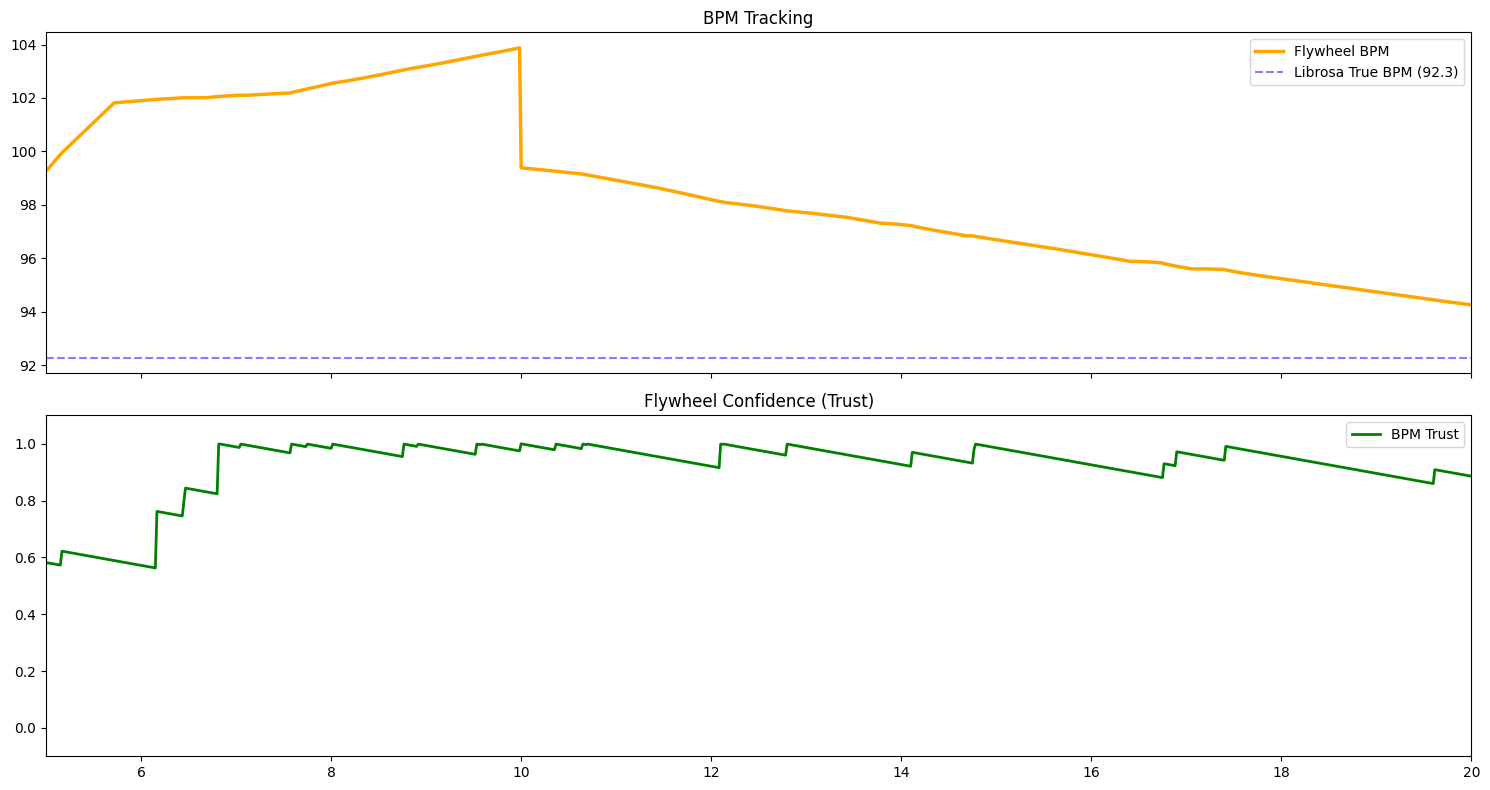

In [6]:
import matplotlib.pyplot as plt

time_arr = np.array(history_time)
bpm_arr = np.array(history_bpm)
bpm_trust_arr = np.array(history_bpm_trust)

fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Select a 15 second slice to see the details clearly
time_slice = (5.0, 20.0)
slice_mask = (time_arr >= time_slice[0]) & (time_arr <= time_slice[1])
slice_times = time_arr[slice_mask]

# 1. Target BPM vs True BPM Background
true_bpm = tempo_librosa[0] if isinstance(tempo_librosa, (list, np.ndarray)) else tempo_librosa
axs[0].plot(slice_times, bpm_arr[slice_mask], color="orange", linewidth=2.5, label="Flywheel BPM")
axs[0].axhline(true_bpm, color="blue", linestyle="--", alpha=0.5, label=f"Librosa True BPM ({true_bpm:.1f})")
axs[0].set_title("BPM Tracking")
axs[0].legend(loc="upper right")

# 2. BPM Trust levels
axs[1].plot(slice_times, bpm_trust_arr[slice_mask], color="green", linewidth=2, label="BPM Trust")
axs[1].set_title("Flywheel Confidence (Trust)")
axs[1].set_ylim(-0.1, 1.1)
axs[1].legend(loc="upper right")

plt.xlim(time_slice)
plt.tight_layout()
plt.show()

